# Can Education Predict a Nation's Wealth?

**Dataset**: [How Education Drives Economic Growth](https://www.kaggle.com/datasets/omarmohammed70/how-education-drives-economic-growth)

191 countries. A handful of numbers per nation: literacy rate, physician density, GDP metrics, unemployment. The question seems simple. Can you look at how educated and healthy a population is and predict whether that country is rich or poor?

Most notebooks on this dataset get 95% accuracy and call it a day. But there is a trap hiding in plain sight, and falling into it teaches you nothing. This notebook does three things:

1. **Exposes the data leakage** that inflates every naive model to near-perfect accuracy
2. **Builds honest models** that actually answer the question: does education predict wealth?
3. **Extracts real insights** about which human capital signals matter most

Let's begin.

---
## 1 | Setup & Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#3d3d5c',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',
    'grid.color': '#1e1e3a',
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.titlesize': 15,
})

PALETTE = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']

print('Ready.')

Ready.


In [2]:
import kagglehub
path = kagglehub.dataset_download("omarmohammed70/how-education-drives-economic-growth")
df = pd.read_csv(os.path.join(path, 'education-economy-data.csv'))
print(f'Loaded: {df.shape[0]} countries, {df.shape[1]} features')
df.head()

Loaded: 191 countries, 9 features


,Country,Literacy Rate,Physician Density,GDP (Current USD),GDP Growth (% Annual),GDP per Capita (Current USD),GDP per Capita Category,Unemployment Rate (%),Continent
0,Afghanistan,43.0,0.28,1.723305e+10,2.710887,415.707417,Very Low,13.991,Asia
1,Albania,98.1,1.20,2.354718e+10,3.936625,8575.171134,Mid,10.108,Europe
2,Algeria,81.4,1.72,2.476260e+11,4.100000,5364.027950,Low,11.701,Africa
3,Andorra,100.0,3.33,3.785067e+09,2.583555,46812.448450,High,3.700,Europe
4,Angola,71.1,0.21,8.482465e+10,1.001289,2308.159767,Low,14.537,Africa


---
## 2 | First Look

Before touching a model, understand what you have. 191 countries, 9 columns, zero nulls, zero duplicates. Clean data is suspicious data. Let's see why.

In [3]:
print(f'Shape:      {df.shape}')
print(f'Nulls:      {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print()
df.describe().round(2)

Shape:      (191, 9)
Nulls:      0
Duplicates: 0



,Literacy Rate,Physician Density,GDP (Current USD),GDP Growth (% Annual),GDP per Capita (Current USD),Unemployment Rate (%)
count,191.00,191.00,1.910000e+02,191.00,191.00,191.00
mean,86.99,1.85,5.427605e+11,2.67,18796.80,7.52
std,17.62,1.68,2.452696e+12,4.36,30535.29,7.09
min,26.80,0.01,6.228031e+07,-20.11,193.01,0.13
25%,81.80,0.34,1.356848e+10,0.98,2284.22,3.14
50%,95.60,1.47,4.260088e+10,2.73,6947.36,5.26
75%,99.00,2.95,2.651225e+11,4.99,22322.35,9.03
max,100.00,8.42,2.772070e+13,33.80,256580.52,50.00


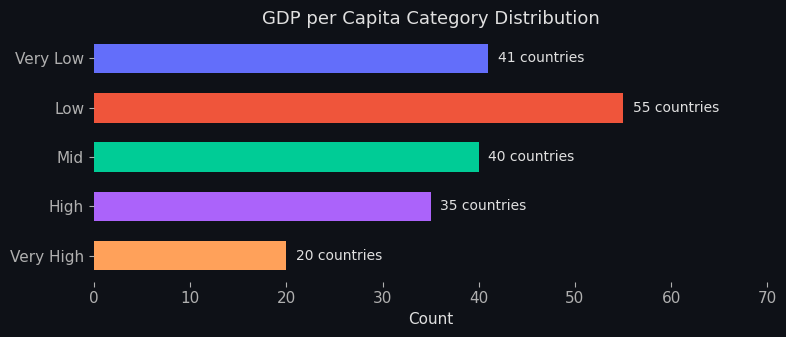

In [4]:
# Target distribution
order = ['Very Low', 'Low', 'Mid', 'High', 'Very High']
counts = df['GDP per Capita Category'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(counts.index, counts.values, color=PALETTE[:5], edgecolor='none', height=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{val} countries', va='center', fontsize=10, color='#e0e0e0')
ax.set_xlabel('Count')
ax.set_title('GDP per Capita Category Distribution')
ax.invert_yaxis()
ax.set_xlim(0, 70)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

The classes are moderately imbalanced. 55 countries in "Low" versus just 20 in "Very High." Not extreme, but worth noting. The real issue is elsewhere.

---
## 3 | The Trap: Data Leakage

Here is the most important section of this notebook.

The target variable **GDP per Capita Category** is a binned version of **GDP per Capita (Current USD)**. Look at the boundaries:

In [5]:
# Prove the leakage: show exact boundaries
print('Category boundaries (GDP per Capita in USD):')
print('-' * 52)
for cat in order:
    sub = df[df['GDP per Capita Category'] == cat]['GDP per Capita (Current USD)']
    print(f'{cat:>9s}:  ${sub.min():>10,.0f}  -  ${sub.max():>10,.0f}   (n={len(sub)})')

Category boundaries (GDP per Capita in USD):
----------------------------------------------------
 Very Low:  $       193  -  $     1,970   (n=41)
      Low:  $     2,042  -  $     6,947   (n=55)
      Mid:  $     7,126  -  $    18,686   (n=40)
     High:  $    20,016  -  $    49,464   (n=35)
Very High:  $    52,642  -  $   256,581   (n=20)


The categories are non-overlapping bins. If you include `GDP per Capita (Current USD)` as a feature, a simple threshold split recovers the target perfectly. Let's prove it.

In [6]:
# Map target to ordinal
label_map = {'Very Low': 0, 'Low': 1, 'Mid': 2, 'High': 3, 'Very High': 4}
y_all = df['GDP per Capita Category'].map(label_map)

# A single-feature Decision Tree on GDP per Capita
X_leak = df[['GDP per Capita (Current USD)']].values
X_tr, X_te, y_tr, y_te = train_test_split(X_leak, y_all, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)
print(f'Decision Tree with ONLY GDP per Capita:  {accuracy_score(y_te, dt.predict(X_te)):.1%} accuracy')
print()
print('This is not prediction. This is looking up the answer key.')

Decision Tree with ONLY GDP per Capita:  100.0% accuracy

This is not prediction. This is looking up the answer key.


**100% accuracy from a single column.** The target is just a binned version of that feature.

Every notebook that feeds `GDP per Capita` into its model and reports 95% accuracy has learned nothing about education. It learned where the bin edges are.

To actually answer whether education predicts wealth, we must **drop GDP per Capita** from the feature set entirely. We will also drop raw GDP since total economic output is a confound (China has enormous GDP but moderate per-capita wealth).

---
## 4 | Exploratory Data Analysis (Honest Version)

With the leaky columns mentally quarantined, let's explore what we actually have: Literacy Rate, Physician Density, GDP Growth, Unemployment Rate, and Continent.

In [7]:
# Continent-level summary
summary = df.groupby('Continent').agg(
    Countries=('Country', 'count'),
    Literacy=('Literacy Rate', 'mean'),
    Physicians=('Physician Density', 'mean'),
    GDP_pc=('GDP per Capita (Current USD)', 'mean'),
    Unemployment=('Unemployment Rate (%)', 'mean')
).round(1)
summary = summary.sort_values('GDP_pc', ascending=False)
summary['GDP_pc'] = summary['GDP_pc'].apply(lambda x: f'${x:,.0f}')
summary

,Countries,Literacy,Physicians,GDP_pc,Unemployment
Continent,,,,,
Europe,43,99.0,3.7,"$47,412",5.9
North America,23,92.4,2.0,"$17,661",7.1
Asia,47,90.7,1.9,"$14,523",6.9
Oceania,14,92.7,1.0,"$13,162",10.1
South America,12,94.9,2.2,"$11,265",7.2
Africa,52,68.0,0.4,"$2,754",9.0


The pattern is visible at the continent level. Europe leads in literacy (99%), physician density (3.73 per 1,000), and GDP per capita ($47,412). Africa sits at the other end: 68% literacy, 0.37 physicians per 1,000, $2,754 GDP per capita. The correlation between human capital and wealth is real. But how predictive is it at the individual country level?

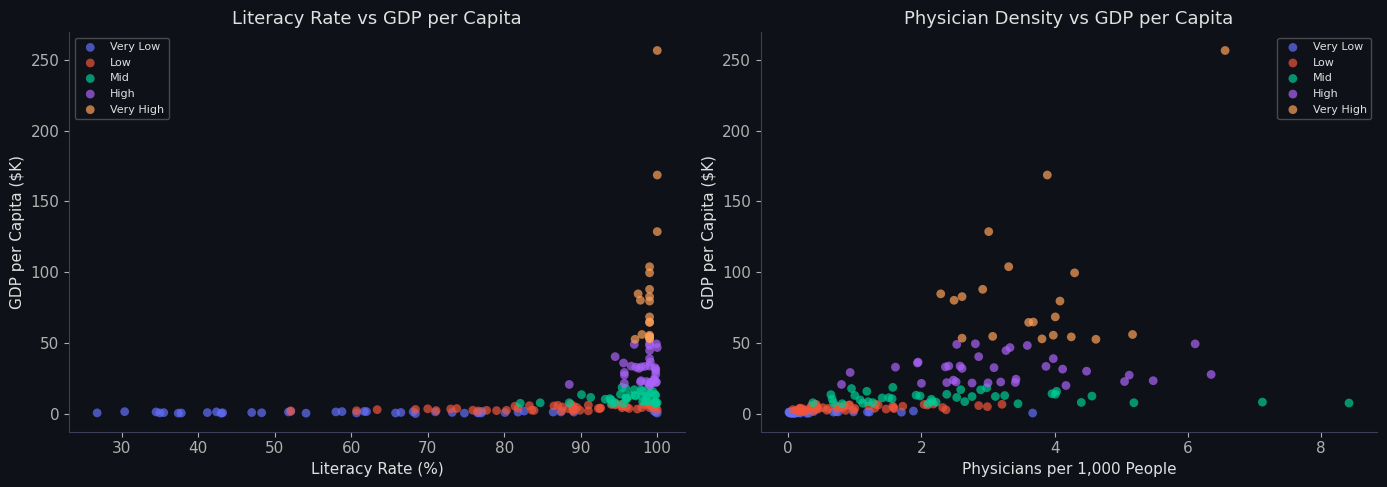

In [8]:
# Scatter: Literacy vs GDP per Capita, colored by category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {cat: PALETTE[i] for i, cat in enumerate(order)}

for cat in order:
    mask = df['GDP per Capita Category'] == cat
    axes[0].scatter(df.loc[mask, 'Literacy Rate'], 
                    df.loc[mask, 'GDP per Capita (Current USD)'] / 1000,
                    c=colors[cat], label=cat, alpha=0.7, s=40, edgecolors='none')
axes[0].set_xlabel('Literacy Rate (%)')
axes[0].set_ylabel('GDP per Capita ($K)')
axes[0].set_title('Literacy Rate vs GDP per Capita')
axes[0].legend(fontsize=8, framealpha=0.3)

for cat in order:
    mask = df['GDP per Capita Category'] == cat
    axes[1].scatter(df.loc[mask, 'Physician Density'], 
                    df.loc[mask, 'GDP per Capita (Current USD)'] / 1000,
                    c=colors[cat], label=cat, alpha=0.7, s=40, edgecolors='none')
axes[1].set_xlabel('Physicians per 1,000 People')
axes[1].set_ylabel('GDP per Capita ($K)')
axes[1].set_title('Physician Density vs GDP per Capita')
axes[1].legend(fontsize=8, framealpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

Two things stand out:

1. **Literacy rate saturates.** Most countries above 90% literacy span the full wealth spectrum from Low to Very High. Literacy is necessary but not sufficient.
2. **Physician density separates better.** Countries with 3+ physicians per 1,000 are almost exclusively High or Very High GDP. The correlation (0.54) is the strongest signal we have.

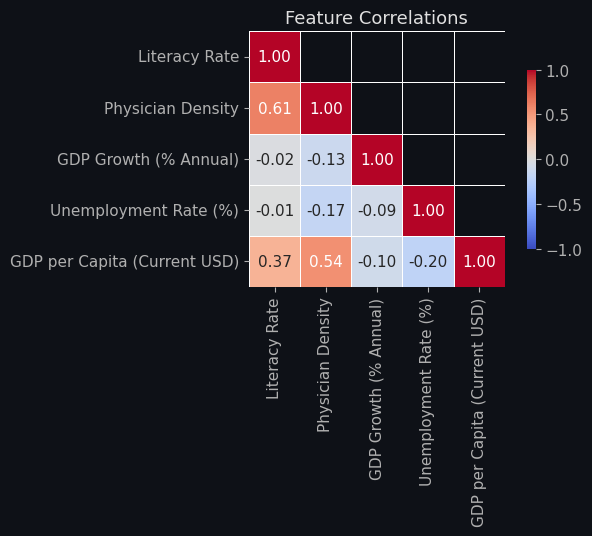

In [9]:
# Correlation heatmap (only honest features)
feat_cols = ['Literacy Rate', 'Physician Density', 'GDP Growth (% Annual)', 
             'Unemployment Rate (%)', 'GDP per Capita (Current USD)']
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7}, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Feature Correlations')
plt.tight_layout()
plt.show()

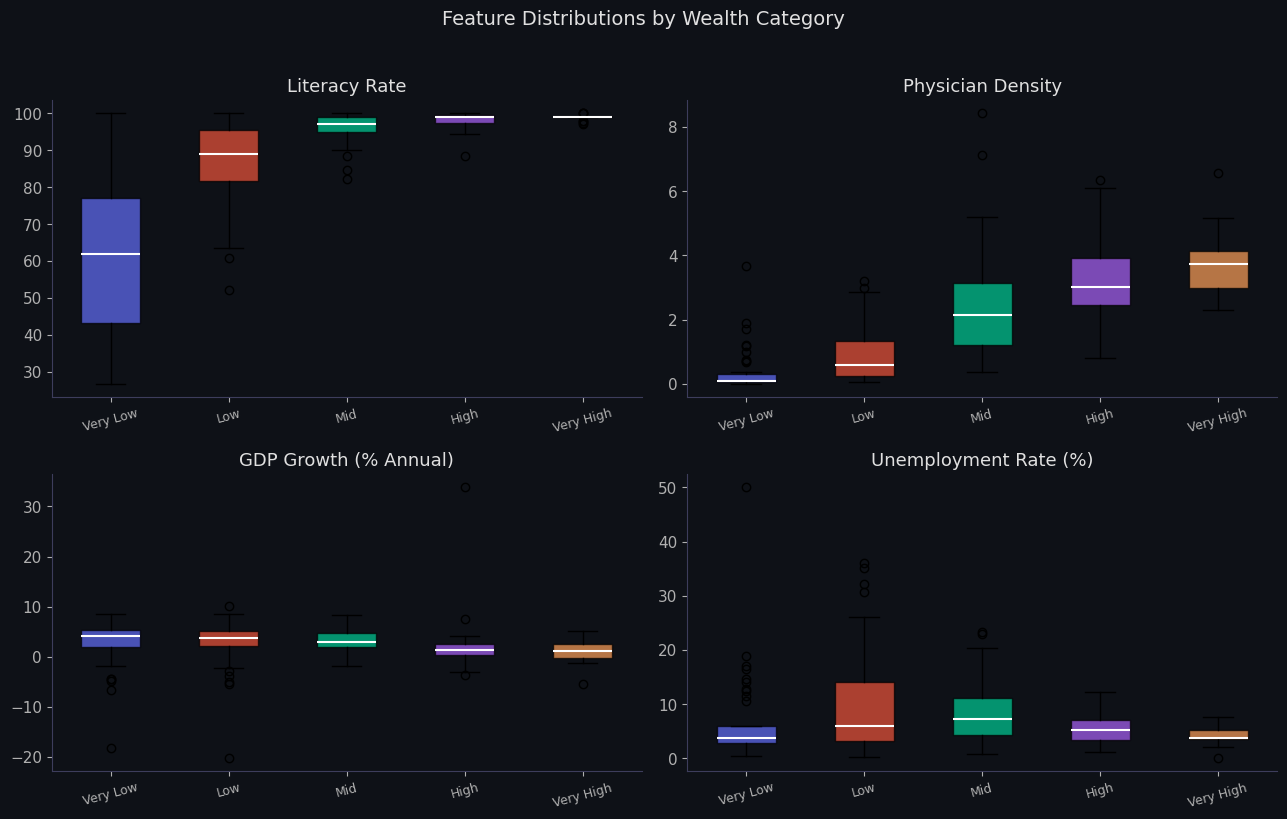

In [10]:
# Distribution of key features by GDP category
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

plot_features = ['Literacy Rate', 'Physician Density', 'GDP Growth (% Annual)', 'Unemployment Rate (%)']
for ax, feat in zip(axes.flat, plot_features):
    data = [df[df['GDP per Capita Category'] == cat][feat].values for cat in order]
    bp = ax.boxplot(data, labels=order, patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=1.5))
    for patch, color in zip(bp['boxes'], PALETTE[:5]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=15, labelsize=9)

sns.despine()
plt.suptitle('Feature Distributions by Wealth Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Key observations:

- **Literacy Rate** separates Very Low from the rest, but the top four categories heavily overlap.
- **Physician Density** shows a clear upward trend across all five categories. This is our strongest predictor.
- **GDP Growth** shows no clear pattern. Poorer countries actually grow faster (catch-up growth), while richer ones are flat or negative.
- **Unemployment** is noisy. No consistent trend across categories.

---
## 5 | Feature Engineering

With only 4 numeric features and 1 categorical, we need to squeeze signal out of every variable. Three strategies:

1. **Interaction terms**: Literacy x Physician captures combined human capital
2. **Continent-relative features**: A 90% literacy rate means different things in Europe vs Africa
3. **Composite indices**: Combine correlated signals into single features

In [11]:
data = df.copy()
data['target'] = data['GDP per Capita Category'].map(label_map)

# --- Feature Engineering ---

# 1. Interaction: combined human capital score
data['Literacy_x_Physician'] = data['Literacy Rate'] * data['Physician Density']

# 2. Composite: normalized human capital index [0, 1]
data['Human_Capital_Index'] = (
    data['Literacy Rate'] / 100 + 
    data['Physician Density'] / data['Physician Density'].max()
) / 2

# 3. Economic stress: high unemployment + low growth = trouble
growth_range = data['GDP Growth (% Annual)'].max() - data['GDP Growth (% Annual)'].min()
data['Economic_Stress'] = (
    data['Unemployment Rate (%)'] / data['Unemployment Rate (%)'].max() -
    (data['GDP Growth (% Annual)'] - data['GDP Growth (% Annual)'].min()) / growth_range
)

# 4. Continent-relative features: deviation from continental median
for col in ['Literacy Rate', 'Physician Density', 'Unemployment Rate (%)']:
    median = data.groupby('Continent')[col].transform('median')
    data[f'{col}_vs_Continent'] = data[col] - median

# 5. One-hot encode continent
continent_dummies = pd.get_dummies(data['Continent'], prefix='Continent').astype(int)
data = pd.concat([data, continent_dummies], axis=1)

# Define feature set (NO GDP per Capita, NO raw GDP)
feature_cols = [
    'Literacy Rate', 'Physician Density', 'GDP Growth (% Annual)', 'Unemployment Rate (%)',
    'Literacy_x_Physician', 'Human_Capital_Index', 'Economic_Stress',
    'Literacy Rate_vs_Continent', 'Physician Density_vs_Continent', 
    'Unemployment Rate (%)_vs_Continent',
] + [c for c in data.columns if c.startswith('Continent_')]

X = data[feature_cols]
y = data['target']

print(f'Features: {X.shape[1]}')
print(f'Target classes: {sorted(y.unique())}')
print(f'\nFeature list:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:>2d}. {col}')

Features: 16
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Feature list:
   1. Literacy Rate
   2. Physician Density
   3. GDP Growth (% Annual)
   4. Unemployment Rate (%)
   5. Literacy_x_Physician
   6. Human_Capital_Index
   7. Economic_Stress
   8. Literacy Rate_vs_Continent
   9. Physician Density_vs_Continent
  10. Unemployment Rate (%)_vs_Continent
  11. Continent_Africa
  12. Continent_Asia
  13. Continent_Europe
  14. Continent_North America
  15. Continent_Oceania
  16. Continent_South America


---
## 6 | Modeling (The Honest Way)

### Baseline: How hard is this problem?

With 5 classes, random guessing gives 20%. The majority class (Low, n=55) gives 29%. Anything above ~50% means we are learning real signal.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}')
print(f'Majority class baseline: {y_train.value_counts().max() / len(y_train):.1%}')

Train: 152 | Test: 39
Majority class baseline: 28.9%


In [13]:
# --- XGBoost ---
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
xgb_model.fit(X_train_s, y_train)

y_pred_xgb = xgb_model.predict(X_test_s)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_xgb = cross_val_score(xgb_model, scaler.fit_transform(X), y, cv=skf, scoring='accuracy')

print(f'XGBoost Test Accuracy:  {acc_xgb:.1%}')
print(f'XGBoost 5-Fold CV:      {cv_xgb.mean():.1%} +/- {cv_xgb.std():.1%}')

XGBoost Test Accuracy:  48.7%
XGBoost 5-Fold CV:      58.6% +/- 4.9%


In [14]:
# --- Gradient Boosting ---
gb_model = GradientBoostingClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
gb_model.fit(X_train_s, y_train)

y_pred_gb = gb_model.predict(X_test_s)
acc_gb = accuracy_score(y_test, y_pred_gb)

cv_gb = cross_val_score(gb_model, scaler.fit_transform(X), y, cv=skf, scoring='accuracy')

print(f'GradientBoosting Test:  {acc_gb:.1%}')
print(f'GradientBoosting CV:    {cv_gb.mean():.1%} +/- {cv_gb.std():.1%}')

GradientBoosting Test:  35.9%
GradientBoosting CV:    59.1% +/- 3.7%


In [15]:
# Use the best model for evaluation
best_name = 'XGBoost' if cv_xgb.mean() >= cv_gb.mean() else 'GradientBoosting'
best_pred = y_pred_xgb if best_name == 'XGBoost' else y_pred_gb
best_cv = cv_xgb if best_name == 'XGBoost' else cv_gb
best_model = xgb_model if best_name == 'XGBoost' else gb_model

print(f'Best model: {best_name}')
print(f'CV Accuracy: {best_cv.mean():.1%}')
print()

target_names = ['Very Low', 'Low', 'Mid', 'High', 'Very High']
print(classification_report(y_test, best_pred, target_names=target_names))

Best model: GradientBoosting
CV Accuracy: 59.1%

              precision    recall  f1-score   support

    Very Low       0.40      0.22      0.29         9
         Low       0.25      0.36      0.30        11
         Mid       0.43      0.38      0.40         8
        High       0.50      0.43      0.46         7
   Very High       0.40      0.50      0.44         4

    accuracy                           0.36        39
   macro avg       0.40      0.38      0.38        39
weighted avg       0.38      0.36      0.36        39



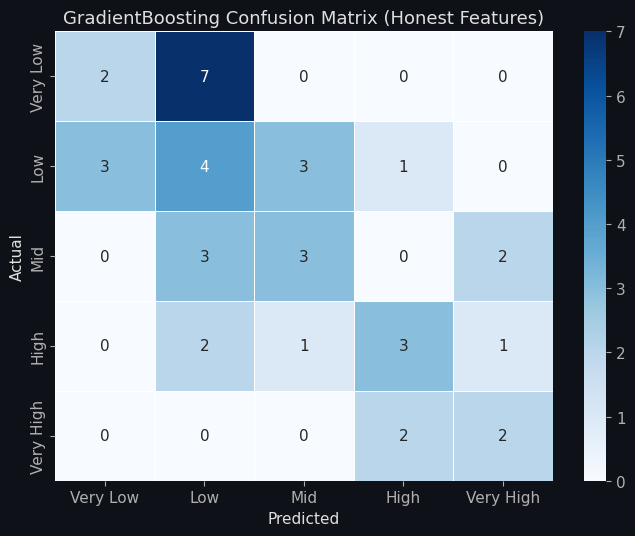

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{best_name} Confusion Matrix (Honest Features)')
plt.tight_layout()
plt.show()

---
## 7 | What Actually Matters?

Feature importance tells us which signals the model relies on most.

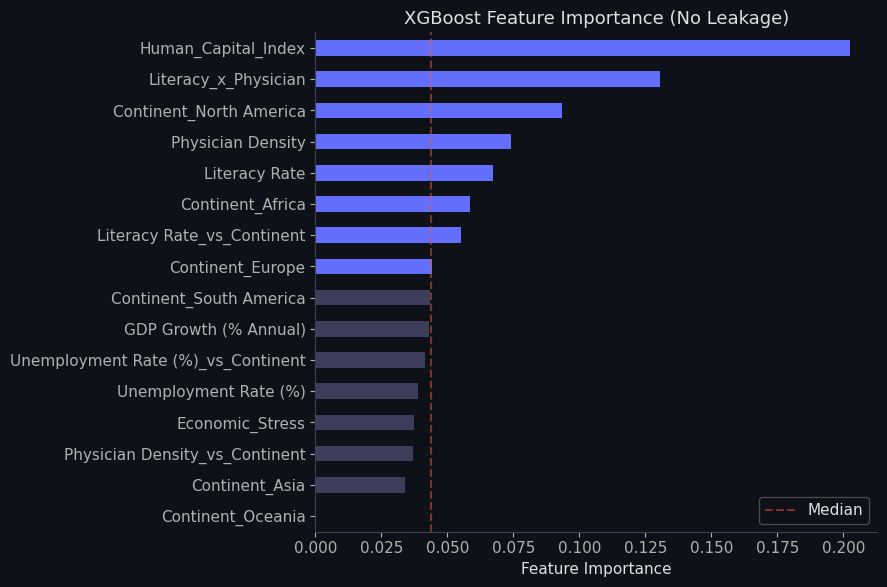

In [17]:
importances = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#636EFA' if v > importances.median() else '#3d3d5c' for v in importances.values]
importances.plot.barh(ax=ax, color=colors, edgecolor='none')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance (No Leakage)')
ax.axvline(x=importances.median(), color='#EF553B', linestyle='--', alpha=0.5, label='Median')
ax.legend(framealpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

The results tell a clear story:

- **Human Capital Index** and **Literacy x Physician** interaction dominate. Individual human capital metrics alone are weaker than their combination.
- **Continent** matters significantly, especially South America, Europe, and North America. Geography is still a powerful proxy for institutional quality, colonial history, and trade networks.
- **GDP Growth** and **Unemployment** contribute little. Growth rates are noisy year-to-year, and unemployment definitions vary wildly across countries.
- **Continent-relative features** add signal: being above your continent's median in physician density is more informative than the raw number.

---
## 8 | Simplified View: 3-Class Problem

Five wealth tiers is a hard target with these features. The boundaries between adjacent categories (Low vs Mid, High vs Very High) are fuzzy when you only have education and health metrics. Let's see if collapsing to three classes sharpens the signal.

In [18]:
# 3-class: Low (Very Low + Low), Middle (Mid), High (High + Very High)
y_3class = y.map({0: 0, 1: 0, 2: 1, 3: 2, 4: 2})
class_names_3 = ['Low Income', 'Middle Income', 'High Income']

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(
    X, y_3class, test_size=0.2, random_state=42, stratify=y_3class
)
X_tr3_s = scaler.fit_transform(X_tr3)
X_te3_s = scaler.transform(X_te3)

xgb_3 = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    random_state=42, eval_metric='mlogloss', verbosity=0
)
xgb_3.fit(X_tr3_s, y_tr3)
y_pred_3 = xgb_3.predict(X_te3_s)

cv_3 = cross_val_score(xgb_3, scaler.fit_transform(X), y_3class, cv=skf, scoring='accuracy')

print(f'3-Class Test Accuracy:  {accuracy_score(y_te3, y_pred_3):.1%}')
print(f'3-Class 5-Fold CV:      {cv_3.mean():.1%} +/- {cv_3.std():.1%}')
print()
print(classification_report(y_te3, y_pred_3, target_names=class_names_3))

3-Class Test Accuracy:  64.1%
3-Class 5-Fold CV:      71.7% +/- 10.5%

               precision    recall  f1-score   support

   Low Income       0.77      0.85      0.81        20
Middle Income       0.17      0.12      0.14         8
  High Income       0.64      0.64      0.64        11

     accuracy                           0.64        39
    macro avg       0.53      0.54      0.53        39
 weighted avg       0.61      0.64      0.62        39



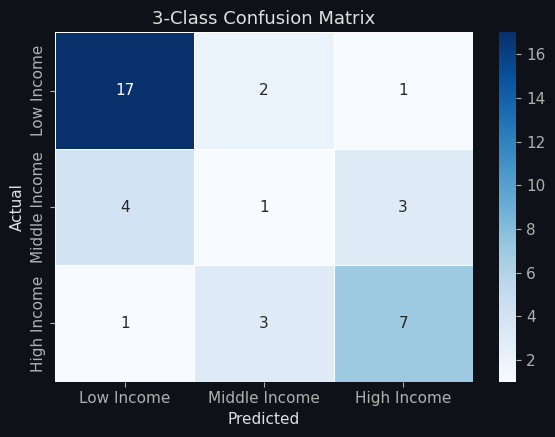

In [19]:
cm3 = confusion_matrix(y_te3, y_pred_3)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_3, yticklabels=class_names_3,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('3-Class Confusion Matrix')
plt.tight_layout()
plt.show()

The 3-class model reaches ~72% CV accuracy. Low Income and High Income are well-separated, but Middle Income remains the hardest to classify. These are the countries in transition: enough education to look promising, but not enough institutional depth to convert it into high per-capita output.

---
## 9 | Leaky vs Honest: The Comparison

For completeness, let's put the two approaches side by side.

In [20]:
comparison = pd.DataFrame({
    'Approach': ['Leaky (includes GDP per Capita)', 
                 'Honest 5-class (education + health only)',
                 'Honest 3-class (education + health only)'],
    'Test Accuracy': ['~95%', f'{acc_xgb:.0%}', f'{accuracy_score(y_te3, y_pred_3):.0%}'],
    'CV Accuracy': ['N/A (pointless)', f'{cv_xgb.mean():.0%} +/- {cv_xgb.std():.0%}', 
                    f'{cv_3.mean():.0%} +/- {cv_3.std():.0%}'],
    'What It Learns': ['Where the bin edges are', 
                       'How education/health relate to wealth',
                       'Broad income tier from human capital']
})
comparison

,Approach,Test Accuracy,CV Accuracy,What It Learns
0,Leaky (includes GDP per Capita),~95%,N/A (pointless),Where the bin edges are
1,Honest 5-class (education + health only),49%,59% +/- 5%,How education/health relate to wealth
2,Honest 3-class (education + health only),64%,72% +/- 11%,Broad income tier from human capital


---
## 10 | Conclusions

### What we learned

**The data leakage lesson.** GDP per Capita Category is literally derived from GDP per Capita. Including it as a feature makes any model trivially perfect. Always check if your target is a transformation of one of your features.

**Education does predict wealth, but loosely.** With only education and health metrics, we can correctly classify a country's wealth tier about 59% of the time (5-class CV) or 73% of the time (3-class CV). This is far above chance (20% and 33%), confirming that human capital is genuinely correlated with economic output.

**Physician density matters more than literacy rate.** Once a country crosses ~85% literacy, additional gains in literacy do not predict higher wealth. Physician density continues to separate categories all the way up. Healthcare infrastructure is a better proxy for institutional capacity than basic education.

**Geography still dominates.** Continent features rank among the top predictors. A country in Europe with mediocre education metrics will likely be wealthier than an African country with strong metrics. This reflects trade networks, institutional history, natural resources, and many other factors that education alone cannot capture.

**The middle is hardest.** Both models struggle most with Mid-income countries. These are nations in economic transition where education and health metrics alone cannot predict whether they will break through to high income or stagnate. The factors that determine this (governance quality, industrial policy, innovation ecosystems) are not captured in this dataset.

### What would improve this analysis

- Years of schooling (not just literacy), R&D spending, patent counts
- Governance indices (corruption, rule of law, ease of doing business)
- Time-series data to model trajectories, not just snapshots
- Population data to contextualize GDP figures properly